In [1]:
# Проверяем окружение и ставим нужное
import sys, subprocess

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

# trimesh — основная библиотека
install("trimesh")

# rtree — для быстрого AABB spatial indexing (ускоряет contains)
install("rtree")

# pyembree — C++ BVH для ray casting (необязательно, но ускоряет в 10-50x)
# На Mac: conda install -c conda-forge pyembree
# В Colab: может не установиться, trimesh использует NumPy fallback
try:
    install("pyembree")
    print("pyembree установлен (быстрый ray casting)")
except:
    print("pyembree не установился, используем NumPy fallback (медленнее)")

import trimesh
import numpy as np
from pathlib import Path
import time
print(f"trimesh version: {trimesh.__version__}")


pyembree установлен (быстрый ray casting)
trimesh version: 3.23.5


In [5]:
# Укажи сборку: маленькая (5 MB) или большая (137 MB)
ASSEMBLY = "20530_2246503a"   # маленькая, для быстрого теста
# ASSEMBLY = "7778_3a9748b3"  # большая

DATA_DIR = Path("data") / ASSEMBLY
# Если step1 уже запущен, используем preprocessed_data:
PREPROC_DIR = Path("preprocessed_data") / ASSEMBLY

# --- Вариант А: грузим из preprocessed_data (после step1) ---
if (PREPROC_DIR / "combined_mesh.obj").exists():
    mesh = trimesh.load(str(PREPROC_DIR / "combined_mesh.obj"), force="mesh")
    face_labels = np.load(PREPROC_DIR / "face_labels.npy")
    import json
    instance_map = json.loads((PREPROC_DIR / "instance_map.json").read_text())
    print(f"Загружен combined_mesh: {len(mesh.vertices)} вершин, {len(mesh.faces)} граней")
    print(f"Уникальных label: {len(np.unique(face_labels))}")

# --- Вариант Б: грузим напрямую из data/ (если step1 не запущен) ---
else:
    # Грузим все .obj файлы из папки сборки напрямую
    obj_files = sorted(DATA_DIR.glob("*.obj"))
    print(f"Найдено {len(obj_files)} obj файлов")
    
    meshes_by_body = {}
    all_verts, all_faces, all_labels = [], [], []
    v_offset = 0
    
    for label_idx, obj_path in enumerate(obj_files, start=1):
        try:
            m = trimesh.load(str(obj_path), force="mesh")
            if len(m.faces) == 0:
                continue
            meshes_by_body[label_idx] = m
            all_verts.append(m.vertices)
            all_faces.append(m.faces + v_offset)
            all_labels.append(np.full(len(m.faces), label_idx, dtype=np.int32))
            v_offset += len(m.vertices)
        except Exception as e:
            print(f"Ошибка загрузки {obj_path.name}: {e}")
    
    verts = np.concatenate(all_verts)
    faces = np.concatenate(all_faces)
    face_labels = np.concatenate(all_labels)
    mesh = trimesh.Trimesh(vertices=verts, faces=faces, process=False)
    print(f"Загружено: {len(mesh.vertices)} вершин, {len(mesh.faces)} граней, {len(meshes_by_body)} тел")


Загружен combined_mesh: 11421 вершин, 22814 граней
Уникальных label: 8


In [6]:
def split_mesh_by_labels(mesh, face_labels):
    """
    Разбивает combined_mesh обратно на отдельные тела по face_labels.
    Возвращает dict {label: trimesh.Trimesh}
    """
    meshes_by_label = {}
    unique_labels = np.unique(face_labels)
    unique_labels = unique_labels[unique_labels > 0]  # убираем фон (label=0)
    
    for lbl in unique_labels:
        face_mask = face_labels == lbl
        sub_faces = mesh.faces[face_mask]
        
        # Находим уникальные вершины этого тела
        used_verts_idx = np.unique(sub_faces)
        vert_remap = np.zeros(len(mesh.vertices), dtype=np.int64)
        vert_remap[used_verts_idx] = np.arange(len(used_verts_idx))
        
        sub_verts = mesh.vertices[used_verts_idx]
        sub_faces_remapped = vert_remap[sub_faces]
        
        try:
            m = trimesh.Trimesh(vertices=sub_verts, faces=sub_faces_remapped, process=False)
            if len(m.faces) > 0:
                meshes_by_label[lbl] = m
        except Exception:
            pass
    
    print(f"Разбито на {len(meshes_by_label)} тел")
    return meshes_by_label

# Только если грузили из preprocessed_data:
if 'instance_map' in dir() or 'instance_map' in locals():
    meshes_by_label = split_mesh_by_labels(mesh, face_labels)
    print("Пример тел:", list(meshes_by_label.keys())[:5])


Разбито на 8 тел
Пример тел: [1, 2, 3, 4, 5]


In [8]:
def extract_outer_shell_contains(mesh, face_labels, meshes_by_label, eps_factor=1e-4):
    """
    Для каждой грани тела A: проверяем, не находится ли точка 
    face_center + normal * eps внутри другого тела B.
    
    Если да → грань скрыта (контакт или перекрытие).
    Если нет → грань на внешней оболочке.
    
    Параметры:
        eps_factor: насколько смещаем точку наружу от грани (относительно bbox сборки)
    
    Возвращает:
        outer_mask: bool array len=N_faces (True = внешняя грань)
    """
    bbox_size = (mesh.vertices.max(axis=0) - mesh.vertices.min(axis=0)).max()
    eps = bbox_size * eps_factor
    
    outer_mask = np.ones(len(mesh.faces), dtype=bool)
    labels_arr = face_labels
    unique_labels = np.unique(labels_arr)
    unique_labels = unique_labels[unique_labels > 0]
    
    # Precompute bounding boxes для быстрого отсечения
    bboxes = {}
    for lbl, m in meshes_by_label.items():
        bboxes[lbl] = (m.vertices.min(axis=0), m.vertices.max(axis=0))
    
    def aabb_overlap(bb1_min, bb1_max, bb2_min, bb2_max, margin=0.0):
        """Проверка перекрытия двух AABB (axis-aligned bounding boxes)"""
        return np.all(bb1_min - margin <= bb2_max) and np.all(bb2_min - margin <= bb1_max)
    
    n_checked = 0
    n_skipped_aabb = 0
    
    for i, lbl_a in enumerate(unique_labels):
        mesh_a = meshes_by_label.get(lbl_a)
        if mesh_a is None:
            continue
        
        face_mask_a = labels_arr == lbl_a
        face_idx_a = np.where(face_mask_a)[0]
        
        # Центры граней + смещение по нормали
        normals_a = mesh_a.face_normals  # (F_a, 3)
        centers_a = mesh_a.triangles.mean(axis=1)  # (F_a, 3)
        query_pts = centers_a + normals_a * eps  # (F_a, 3)
        
        # Для каждой грани: is_hidden[i] = True если точка хотя бы в одном теле B
        is_hidden = np.zeros(len(face_idx_a), dtype=bool)
        
        bb_a_min, bb_a_max = bboxes[lbl_a]
        
        for lbl_b, mesh_b in meshes_by_label.items():
            if lbl_b == lbl_a:
                continue
            
            bb_b_min, bb_b_max = bboxes[lbl_b]
            
            # Быстрая проверка AABB перед дорогой операцией contains
            if not aabb_overlap(bb_a_min, bb_a_max, bb_b_min, bb_b_max, margin=eps*2):
                n_skipped_aabb += 1
                continue
            
            n_checked += 1
            
            try:
                # trimesh.contains использует winding number — корректен для watertight meshes
                inside = mesh_b.contains(query_pts)
                is_hidden |= inside
            except Exception:
                pass
        
        # Обновляем маску
        outer_mask[face_idx_a[is_hidden]] = False
        
        if (i + 1) % 10 == 0 or i == len(unique_labels) - 1:
            print(f"  Тел обработано: {i+1}/{len(unique_labels)}, "
                  f"пар проверено: {n_checked}, пропущено AABB: {n_skipped_aabb}")
    
    return outer_mask


# Запуск с замером времени
t0 = time.time()
outer_mask_contains = extract_outer_shell_contains(mesh, face_labels, meshes_by_label)
t1 = time.time()

print(f"\n✅ Время: {t1-t0:.2f} сек")
print(f"Всего граней: {len(outer_mask_contains)}")
print(f"Внешних граней: {outer_mask_contains.sum()} ({outer_mask_contains.mean():.1%})")
print(f"Скрытых граней: {(~outer_mask_contains).sum()} ({(~outer_mask_contains).mean():.1%})")


  Тел обработано: 8/8, пар проверено: 48, пропущено AABB: 8

✅ Время: 11.97 сек
Всего граней: 22814
Внешних граней: 22076 (96.8%)
Скрытых граней: 738 (3.2%)


In [15]:

def extract_outer_shell_raycasting(mesh, n_rays=3):
    """
    Для каждой грани: пускаем n_rays лучей из полусферы вокруг нормали.
    Считаем пересечения с мешом. 
    Если медианное число пересечений чётное → грань снаружи.
    """
    bbox_size = (mesh.vertices.max(axis=0) - mesh.vertices.min(axis=0)).max()
    eps = bbox_size * 1e-5
    
    face_normals = mesh.face_normals          # (F, 3)
    face_centers = mesh.triangles.mean(axis=1)  # (F, 3)
    n_faces = len(face_normals)
    
    def count_intersections_batch(origins, directions):
        ray_idx, face_idx, location = mesh.ray.intersects_location(
            ray_origins=origins,
            ray_directions=directions,
            multiple_hits=True
        )
        counts = np.zeros(len(origins), dtype=np.int32)
        if len(ray_idx) > 0:
            ray_idx_int = np.array(ray_idx, dtype=np.int64)  # ← явное приведение к int
            np.add.at(counts, ray_idx_int, 1)
        return counts
    
    all_outer_votes = np.zeros(n_faces, dtype=np.int32)
    
    t0 = time.time()
    for ray_i in range(n_rays):
        if ray_i == 0:
            directions = face_normals.copy()
        else:
            np.random.seed(ray_i)
            random_dir = np.random.randn(n_faces, 3)
            dot = (random_dir * face_normals).sum(axis=1, keepdims=True)
            tangent = random_dir - dot * face_normals
            norms = np.linalg.norm(tangent, axis=1, keepdims=True)
            # Избегаем деления на ноль
            tangent = np.where(norms > 1e-8, tangent / norms, face_normals)
            angle = np.random.uniform(0.1, 0.5, size=(n_faces, 1))
            directions = np.cos(angle) * face_normals + np.sin(angle) * tangent
            norms2 = np.linalg.norm(directions, axis=1, keepdims=True)
            directions = directions / (norms2 + 1e-8)
        
        origins = face_centers + face_normals * eps
        hits = count_intersections_batch(origins, directions)
        
        # Чётное число пересечений = снаружи → голос "внешняя"
        all_outer_votes += (hits % 2 == 0).astype(np.int32)
        print(f"  Луч {ray_i+1}/{n_rays}: {time.time()-t0:.2f} сек")
    
    print(f"Ray casting ({n_rays} лучей): {time.time()-t0:.2f} сек")
    # Большинство голосов
    outer_mask = all_outer_votes > (n_rays // 2)
    return outer_mask


# Запуск
t0 = time.time()
outer_mask_raycast = extract_outer_shell_raycasting(mesh, n_rays=3)
t1 = time.time()

print(f"\n✅ Ray Casting время: {t1-t0:.2f} сек")
print(f"Внешних граней: {outer_mask_raycast.sum()} ({outer_mask_raycast.mean():.1%})")


  Луч 1/3: 11.24 сек
  Луч 2/3: 22.23 сек
  Луч 3/3: 33.54 сек
Ray casting (3 лучей): 33.54 сек

✅ Ray Casting время: 33.55 сек
Внешних граней: 22810 (100.0%)


In [16]:
gt_path = PREPROC_DIR / "outer_face_mask.npy" if 'PREPROC_DIR' in dir() else None

if gt_path and gt_path.exists():
    outer_gt = np.load(gt_path)
    print(f"Ground truth (рендеринг): {outer_gt.sum()} внешних граней ({outer_gt.mean():.1%})")
    
    # Сравнение contains vs GT
    if 'outer_mask_contains' in dir():
        agree_contains = (outer_mask_contains == outer_gt).mean()
        print(f"\nContains vs GT: совпадение = {agree_contains:.1%}")
        # Что contains считает внутренним, но GT считает внешним (ложное удаление)
        false_neg = (~outer_mask_contains & outer_gt).sum()
        # Что contains считает внешним, но GT считает внутренним (пропущенные скрытые)
        false_pos = (outer_mask_contains & ~outer_gt).sum()
        print(f"  Ложно удалённых (грань внешняя, но contains её убрал): {false_neg}")
        print(f"  Пропущенных скрытых (грань скрыта, но contains её оставил): {false_pos}")
    
    # Сравнение raycast vs GT
    if 'outer_mask_raycast' in dir():
        agree_ray = (outer_mask_raycast == outer_gt).mean()
        print(f"\nRaycast vs GT: совпадение = {agree_ray:.1%}")
        false_neg_r = (~outer_mask_raycast & outer_gt).sum()
        false_pos_r = (outer_mask_raycast & ~outer_gt).sum()
        print(f"  Ложно удалённых: {false_neg_r}")
        print(f"  Пропущенных скрытых: {false_pos_r}")
else:
    print("Ground truth (step2) не найден. Запусти step2 для сравнения.")
    print("Сравниваем contains vs raycast между собой:")
    if 'outer_mask_contains' in dir() and 'outer_mask_raycast' in dir():
        agree = (outer_mask_contains == outer_mask_raycast).mean()
        print(f"Contains vs Raycast: совпадение = {agree:.1%}")


Ground truth (рендеринг): 17608 внешних граней (77.2%)

Contains vs GT: совпадение = 78.7%
  Ложно удалённых (грань внешняя, но contains её убрал): 196
  Пропущенных скрытых (грань скрыта, но contains её оставил): 4664

Raycast vs GT: совпадение = 77.2%
  Ложно удалённых: 4
  Пропущенных скрытых: 5206


/var/folders/nn/mgs_bzg54359bbbfz3j0th4h0000gn/T/ipykernel_91908/718971358.py:64: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/nn/mgs_bzg54359bbbfz3j0th4h0000gn/T/ipykernel_91908/718971358.py:64: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/neonilllai/miniconda3/envs/fusion_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/neonilllai/miniconda3/envs/fusion_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


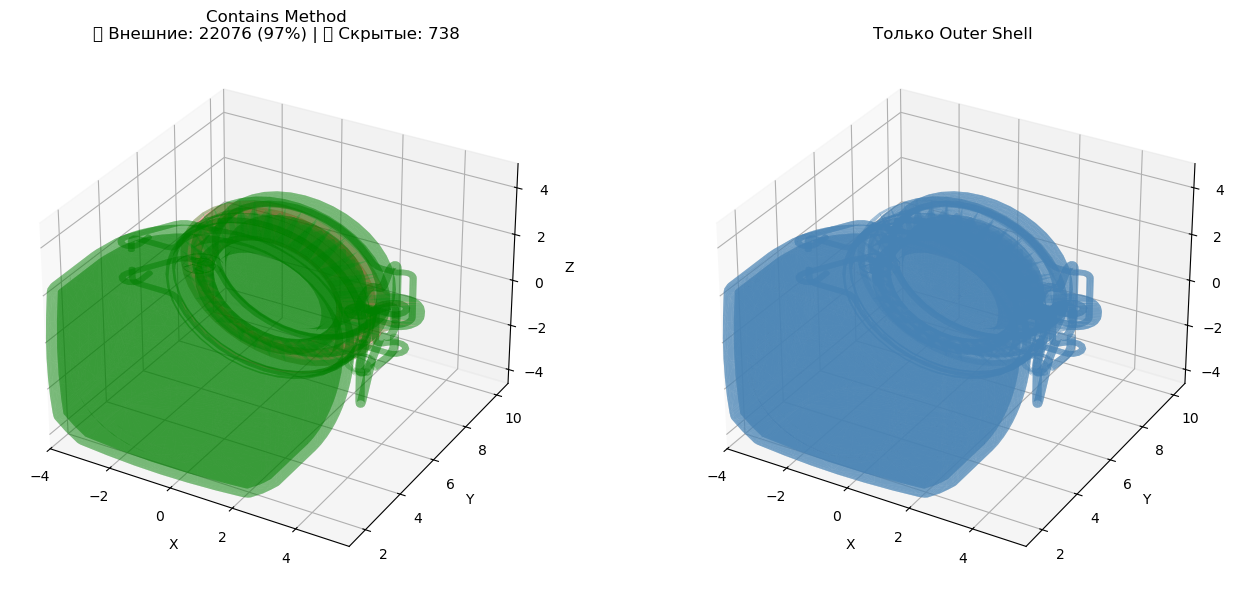

In [17]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def visualize_outer_shell(mesh, outer_mask, title="Outer Shell", max_faces=50000):
    """
    Показывает внешние грани (зелёные) и скрытые грани (красные).
    Для больших мешей делает subsampling.
    """
    # Subsample если слишком много граней
    n_faces = len(mesh.faces)
    if n_faces > max_faces:
        idx = np.random.choice(n_faces, max_faces, replace=False)
        faces_show = mesh.faces[idx]
        mask_show = outer_mask[idx]
        print(f"Показываем {max_faces} из {n_faces} граней (subsampled)")
    else:
        faces_show = mesh.faces
        mask_show = outer_mask
    
    verts = mesh.vertices
    
    # Строим цвета: зелёный = внешний, красный = скрытый
    colors = np.where(mask_show[:, None], [0.2, 0.8, 0.2, 0.3], [0.8, 0.2, 0.2, 0.15])
    
    fig = plt.figure(figsize=(14, 6))
    
    # Вид 1: combined
    ax1 = fig.add_subplot(121, projection='3d')
    outer_faces = faces_show[mask_show]
    inner_faces = faces_show[~mask_show]
    
    if len(outer_faces) > 0:
        poly_outer = Poly3DCollection(verts[outer_faces[:min(20000, len(outer_faces))]], 
                                       alpha=0.3, facecolor='green', edgecolor='none')
        ax1.add_collection3d(poly_outer)
    
    if len(inner_faces) > 0:
        poly_inner = Poly3DCollection(verts[inner_faces[:min(5000, len(inner_faces))]], 
                                       alpha=0.15, facecolor='red', edgecolor='none')
        ax1.add_collection3d(poly_inner)
    
    bbox = verts.max(axis=0) - verts.min(axis=0)
    center = verts.mean(axis=0)
    r = bbox.max() / 2
    ax1.set_xlim(center[0]-r, center[0]+r)
    ax1.set_ylim(center[1]-r, center[1]+r)
    ax1.set_zlim(center[2]-r, center[2]+r)
    ax1.set_title(f"{title}\n🟢 Внешние: {outer_mask.sum()} ({outer_mask.mean():.0%}) | 🔴 Скрытые: {(~outer_mask).sum()}")
    ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
    
    # Вид 2: только внешние (outer shell)
    ax2 = fig.add_subplot(122, projection='3d')
    if len(outer_faces) > 0:
        poly2 = Poly3DCollection(verts[outer_faces[:min(20000, len(outer_faces))]], 
                                  alpha=0.5, facecolor='steelblue', edgecolor='none')
        ax2.add_collection3d(poly2)
    ax2.set_xlim(center[0]-r, center[0]+r)
    ax2.set_ylim(center[1]-r, center[1]+r)
    ax2.set_zlim(center[2]-r, center[2]+r)
    ax2.set_title("Только Outer Shell")
    ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')
    
    plt.tight_layout()
    plt.show()


# Визуализируем результат contains (или raycast если contains не запускали)
if 'outer_mask_contains' in dir():
    visualize_outer_shell(mesh, outer_mask_contains, title="Contains Method")
elif 'outer_mask_raycast' in dir():
    visualize_outer_shell(mesh, outer_mask_raycast, title="Ray Casting Method")


In [21]:
from label_mesh import label_mesh
label_mesh('7778_3a9748b3', 'preprocessed_data')

In [22]:
# Тест на большой сборке
ASSEMBLY_LARGE = "7778_3a9748b3"
PREPROC_LARGE = Path("preprocessed_data") / ASSEMBLY_LARGE

if (PREPROC_LARGE / "combined_mesh.obj").exists():
    print(f"Загружаем большую сборку {ASSEMBLY_LARGE}...")
    t0 = time.time()
    mesh_large = trimesh.load(str(PREPROC_LARGE / "combined_mesh.obj"), force="mesh")
    labels_large = np.load(PREPROC_LARGE / "face_labels.npy")
    t_load = time.time() - t0
    print(f"Загрузка: {t_load:.1f} сек | {len(mesh_large.faces)} граней")
    
    meshes_large = split_mesh_by_labels(mesh_large, labels_large)
    
    t0 = time.time()
    mask_large = extract_outer_shell_contains(mesh_large, labels_large, meshes_large)
    t_contains = time.time() - t0
    print(f"\n⏱ Contains: {t_contains:.2f} сек на {len(mesh_large.faces)} гранях")
    
    t0 = time.time()
    mask_large_ray = extract_outer_shell_raycasting(mesh_large, n_rays=1)
    t_ray = time.time() - t0
    print(f"⏱ Raycast (1 луч): {t_ray:.2f} сек на {len(mesh_large.faces)} гранях")
else:
    print("Большая сборка не найдена в preprocessed_data. Запусти step1 для неё.")


Загружаем большую сборку 7778_3a9748b3...
Загрузка: 0.5 сек | 283814 граней
Разбито на 167 тел
  Тел обработано: 10/167, пар проверено: 102, пропущено AABB: 1558
  Тел обработано: 20/167, пар проверено: 292, пропущено AABB: 3028
  Тел обработано: 30/167, пар проверено: 387, пропущено AABB: 4593
  Тел обработано: 40/167, пар проверено: 491, пропущено AABB: 6149
  Тел обработано: 50/167, пар проверено: 599, пропущено AABB: 7701
  Тел обработано: 60/167, пар проверено: 708, пропущено AABB: 9252
  Тел обработано: 70/167, пар проверено: 789, пропущено AABB: 10831
  Тел обработано: 80/167, пар проверено: 876, пропущено AABB: 12404
  Тел обработано: 90/167, пар проверено: 960, пропущено AABB: 13980
  Тел обработано: 100/167, пар проверено: 1084, пропущено AABB: 15516
  Тел обработано: 110/167, пар проверено: 1142, пропущено AABB: 17118
  Тел обработано: 120/167, пар проверено: 1236, пропущено AABB: 18684
  Тел обработано: 130/167, пар проверено: 1325, пропущено AABB: 20255
  Тел обработано: 1

: 